# 手順2：現行モデルの再現とリークの確認

CLAUDE.md §7 の手順2（§6 の参考比較）。現行モデル（入力：流動先端温度 T・樹脂圧力 P・せん断速度 γ̇）を再現し、P による目的変数のリークを数値で確認する。

- データ：`02_機械学習データ/NR500/00_バージンPP実験データ/学習データ6月発表時.csv`（既存の CSV とノートは変更しない）
- 図・表の保存先：`results/step2/`（図の文字は日本語。フォントは IPAexGothic）
- 計算は自然対数 ln で行う。単位：η [Pa·s]、γ̇ [1/s]、P [Pa]、T [K]（表示は ℃）、厚み H [mm]
- 乱数シードは 42 に固定する

| 記号 | モデル | 入力 |
|---|---|---|
| M1 | 現行 GPR（ARD Matern 5/2 ＋ ホワイトノイズ） | ln T, ln P, ln γ̇ |
| M2 | 線形回帰 | ln P, ln γ̇ |
| M3 | 線形回帰（粘度の算出式どおり） | ln(P − P2), ln γ̇, ln H |
| M4 | P を外した GPR（M1 と同じ形のカーネル） | ln T, ln γ̇ |

| 記号 | 分割 |
|---|---|
| S1 | せん断速度 500〜1000 1/s の行をテスト（現行ノートと同じ） |
| S2 | ランダム2割（CLAUDE.md §4 の記述。random_state=42） |

## 1. 設定

In [1]:
# セル1：ライブラリと設定
%matplotlib inline
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

SEED = 42
CSV_PATH = os.path.join("..", "02_機械学習データ", "NR500", "00_バージンPP実験データ", "学習データ6月発表時.csv")
OUT_DIR = os.path.join("..", "results", "step2")
os.makedirs(OUT_DIR, exist_ok=True)

FIG_DPI = 200                      # 保存する PNG の解像度
plt.rcParams["figure.dpi"] = 80    # ノート内の表示は小さめにする
pd.set_option("display.width", 200)

# 図の日本語フォント（元のノートと同じ IPAexGothic。ない文字は DejaVu Sans で表示）
try:
    fm.findfont("IPAexGothic", fallback_to_default=False)
except ValueError:
    raise RuntimeError("日本語フォント IPAexGothic が見つかりません。インストールしてからカーネルを再起動してください。")
plt.rcParams["font.family"] = ["IPAexGothic", "DejaVu Sans"]

# CSV の列名
COL_FILE = "元ファイル"
COL_H = "キャビティ厚み"            # [mm]
COL_Q = "射出率 [㎤/s]"             # [cm^3/s]
COL_ETA = "樹脂粘度η(Pa・s)"        # [Pa·s]
COL_SR = "せん断速度γ(1/s)"         # [1/s]
COL_T = "流動中樹脂温度T(℃)"        # [℃] 流動先端温度
COL_P = "流動中樹脂圧力P(Pa)"       # [Pa] 2点目が立ち上がった時の1点目の圧力

print("Python:", sys.executable, "/", sys.version.split()[0])
print("CSV   :", os.path.abspath(CSV_PATH))
print("出力先:", os.path.abspath(OUT_DIR))

Python: C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\.venv\Scripts\python.exe / 3.12.12
CSV   : C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\02_機械学習データ\NR500\00_バージンPP実験データ\学習データ6月発表時.csv
出力先: C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\results\step2


## 2. 読み込みと条件情報

設定温度と条件番号は CSV の列にないため、元ファイル名（例：`001_190℃_020_0.5mm.csv` ＝ ショット番号_設定温度_射出速度の設定値_厚み）から取り出す。条件番号は (設定温度, 厚み, 射出率) の組ごとに振る。

In [2]:
# セル2：CSV の読み込みと条件情報の付与
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(f"読み込み: {len(df)} 行 × {df.shape[1]} 列、欠損 {int(df.isna().sum().sum())} 個")

parts = df[COL_FILE].str.extract(r"^(\d{3})_(\d+)℃_(\d{3})_([\d.]+)mm\.csv$")
assert parts.notna().all().all(), "ファイル名の形式に合わない行がある"
df["shot_no"] = parts[0].astype(int)       # 温度×厚みごとの通し番号
df["Tset_C"] = parts[1].astype(float)      # 加熱シリンダ設定温度 [℃]
df["speed_set"] = parts[2].astype(int)     # 射出速度の設定値（射出率 = 0.531 × この値）
assert np.allclose(parts[3].astype(float), df[COL_H]), "ファイル名の厚みと「キャビティ厚み」列が一致しない"

df["cond_id"] = df.groupby(["Tset_C", COL_H, COL_Q]).ngroup()
n_shots = df.groupby("cond_id").size()
assert df["cond_id"].nunique() == 129 and (n_shots == 10).all(), "129条件 × 10ショットになっていない"
print(f"条件数 {df['cond_id'].nunique()}（各 10 ショット）")
print("設定温度 [℃]  :", sorted(df["Tset_C"].unique().tolist()))
print("厚み [mm]      :", sorted(df[COL_H].unique().tolist()))
print("射出率 [cm3/s] :", sorted(df[COL_Q].unique().tolist()))

# 計算に使う配列
H = df[COL_H].to_numpy()                   # 厚み [mm]
eta = df[COL_ETA].to_numpy()               # 見かけの粘度 [Pa·s]
sr = df[COL_SR].to_numpy()                 # 見かけのせん断速度 [1/s]
P = df[COL_P].to_numpy()                   # 1点目の圧力 [Pa]
T_K = df[COL_T].to_numpy() + 273.15        # 流動先端温度 [K]
Tset = df["Tset_C"].to_numpy()             # 設定温度 [℃]
ln_eta = np.log(eta)

読み込み: 1290 行 × 7 列、欠損 0 個
条件数 129（各 10 ショット）
設定温度 [℃]  : [190.0, 210.0, 230.0]
厚み [mm]      : [0.5, 1.0, 1.5, 2.0]
射出率 [cm3/s] : [1.593, 2.655, 5.31, 10.62, 21.24, 42.48, 63.72, 84.96, 106.2, 127.44, 148.68, 169.92]


## 3. 粘度の算出式の確認（リークの直接確認）

スリット近似では τw = ΔP·H/(2L)、η = τw/γ̇。ΔP = P − P2（P2：2点目が立ち上がった時の2点目の圧力）とすると、

τ = η·γ̇ = H·P/(2L) − H·P2/(2L)

となる。τ を [H·P, H] で切片なしの最小二乗回帰し、センサ間距離 L と P2 を推定する。全行でこの式が成り立てば、P・γ̇・H から η が計算で決まる（P を入力にするとリークになる）。

全行で推定: L = 17.501 mm、P2 = 0.4001 MPa
相対残差: 最大 0.035 %、RMS 0.0101 %

厚みごとに当てはめた場合（all は全行で共通の L・P2）:
H_mm    n    L_mm  P2_MPa  max_abs_rel_resid_pct
 0.5  270 17.4980  0.4020                 0.0116
 1.0  300 17.5067  0.3989                 0.0225
 1.5  360 17.5069  0.3994                 0.0299
 2.0  360 17.5061  0.3997                 0.0286
 all 1290 17.5014  0.4001                 0.0345


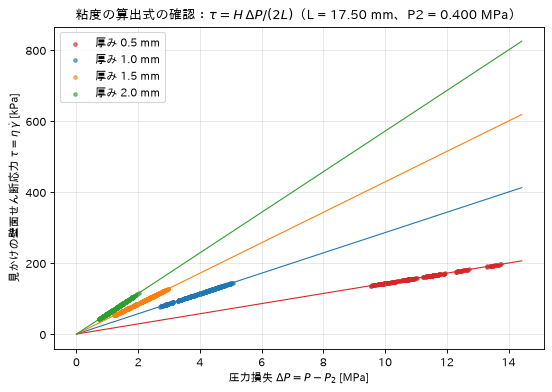

In [3]:
# セル3：τ = η·γ̇ と ΔP = P − P2 の関係
tau = eta * sr                                  # 見かけの壁面せん断応力 [Pa]
A = np.column_stack([H * P, H])
coef, *_ = np.linalg.lstsq(A, tau, rcond=None)
L_mm = 1.0 / (2.0 * coef[0])                    # センサ間距離 [mm]
P2 = -coef[1] / coef[0]                         # 2点目の圧力 [Pa]
rel_res = tau / (A @ coef) - 1.0
dP = P - P2                                     # 粘度の算出に使われた圧力損失 [Pa]

print(f"全行で推定: L = {L_mm:.3f} mm、P2 = {P2 / 1e6:.4f} MPa")
print(f"相対残差: 最大 {np.abs(rel_res).max() * 100:.3f} %、RMS {np.sqrt(np.mean(rel_res ** 2)) * 100:.4f} %")

rows = []
for h in np.unique(H):
    m = H == h
    a, b = np.polyfit(P[m], tau[m], 1)
    rows.append({"H_mm": f"{h}", "n": int(m.sum()), "L_mm": h / (2 * a), "P2_MPa": -b / a / 1e6,
                 "max_abs_rel_resid_pct": np.abs(tau[m] / (a * P[m] + b) - 1).max() * 100})
rows.append({"H_mm": "all", "n": len(H), "L_mm": L_mm, "P2_MPa": P2 / 1e6,
             "max_abs_rel_resid_pct": np.abs(rel_res).max() * 100})
formula_df = pd.DataFrame(rows)
print("\n厚みごとに当てはめた場合（all は全行で共通の L・P2）:")
print(formula_df.round(4).to_string(index=False))
formula_df.to_csv(os.path.join(OUT_DIR, "formula_check.csv"), index=False, encoding="utf-8-sig")

# 図1：τ と ΔP の関係（厚みごと）
H_COLORS = {0.5: "tab:red", 1.0: "tab:blue", 1.5: "tab:orange", 2.0: "tab:green"}
fig, ax = plt.subplots(figsize=(7, 5))
x_line = np.linspace(0, dP.max() * 1.05, 50)
for h in np.unique(H):
    m = H == h
    ax.scatter(dP[m] / 1e6, tau[m] / 1e3, s=10, alpha=0.6, color=H_COLORS[h], label=f"厚み {h} mm")
    ax.plot(x_line / 1e6, h * x_line / (2 * L_mm) / 1e3, color=H_COLORS[h], lw=1)
ax.set_xlabel(r"圧力損失 $\Delta P = P - P_2$ [MPa]")
ax.set_ylabel(r"見かけの壁面せん断応力 $\tau = \eta\,\dot{\gamma}$ [kPa]")
ax.set_title(r"粘度の算出式の確認：$\tau = H\,\Delta P/(2L)$" + f"（L = {L_mm:.2f} mm、P2 = {P2 / 1e6:.3f} MPa）")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig1_formula_check.png"), dpi=FIG_DPI)
plt.show()

## 4. 学習データとテストデータの分割

In [4]:
# セル4：分割
SPLITS = {}
SPLITS["S1"] = (sr >= 500) & (sr <= 1000)                         # 現行ノートと同じ
_, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=SEED)
SPLITS["S2"] = np.isin(np.arange(len(df)), idx_te)                 # 現行ノートの "random" モードと同じ
SPLIT_LABELS = {"S1": "S1：せん断速度 500〜1000 1/s をテスト", "S2": "S2：ランダム2割をテスト"}

cond = df["cond_id"].to_numpy()
for s, te in SPLITS.items():
    c_te, c_tr = set(cond[te]), set(cond[~te])
    print(f"{s}: 学習 {(~te).sum()} 行 / テスト {te.sum()} 行、テストを含む条件 {len(c_te)}、"
          f"学習とテストの両方に入った条件 {len(c_te & c_tr)}")
print("\nS1 のテスト条件（設定温度 ℃, 厚み mm, 射出率 cm3/s）:")
print(df.loc[SPLITS["S1"], ["Tset_C", COL_H, COL_Q]].drop_duplicates().to_string(index=False))

S1: 学習 1200 行 / テスト 90 行、テストを含む条件 9、学習とテストの両方に入った条件 0
S2: 学習 1032 行 / テスト 258 行、テストを含む条件 113、学習とテストの両方に入った条件 113

S1 のテスト条件（設定温度 ℃, 厚み mm, 射出率 cm3/s）:
 Tset_C  キャビティ厚み  射出率 [㎤/s]
  190.0      1.0       5.31
  210.0      1.0       5.31
  230.0      1.0       5.31
  190.0      1.5      10.62
  210.0      1.5      10.62
  230.0      1.5      10.62
  190.0      2.0      21.24
  210.0      2.0      21.24
  230.0      2.0      21.24


## 5. 前処理とモデル

- GPR の前処理は現行ノートと同じにする。標準化と ln η の平均は、分割前の全行で計算する。
- カーネルと最適化の設定も現行ノートと同じにする。現行ノートの自作オプティマイザは L-BFGS-B の途中経過を記録するだけなので、scikit-learn の既定と同じ結果になる。
- M3 の P2 は、セル3で全行から推定した値を使う（測定系の定数とみなす）。

In [5]:
# セル5：前処理（現行ノートと同じ）と、モデル・評価の関数
X_M1 = np.column_stack([np.log(T_K), np.log(P), np.log(sr)])   # M1：ln T, ln P, ln γ̇
X_M2 = np.column_stack([np.log(P), np.log(sr)])                # M2：ln P, ln γ̇
X_M3 = np.column_stack([np.log(dP), np.log(sr), np.log(H)])    # M3：ln(P − P2), ln γ̇, ln H
X_M4 = np.column_stack([np.log(T_K), np.log(sr)])              # M4：ln T, ln γ̇（P を外す）

sc_M1 = StandardScaler().fit(X_M1)
sc_M4 = StandardScaler().fit(X_M4)
y_mean = ln_eta.mean()
y_c = ln_eta - y_mean

MODELS = {
    "M1": {"kind": "gpr", "X": sc_M1.transform(X_M1), "inputs": ["lnT", "lnP", "lnSR"], "label": r"M1：現行 GPR［$T$, $P$, $\dot{\gamma}$］"},
    "M2": {"kind": "ols", "X": X_M2, "inputs": ["lnP", "lnSR"], "label": r"M2：線形回帰［$\ln P$, $\ln\dot{\gamma}$］"},
    "M3": {"kind": "ols", "X": X_M3, "inputs": ["lnDP", "lnSR", "lnH"], "label": r"M3：線形回帰（算出式）［$\ln(P-P_2)$, $\ln\dot{\gamma}$, $\ln H$］"},
    "M4": {"kind": "gpr", "X": sc_M4.transform(X_M4), "inputs": ["lnT", "lnSR"], "label": r"M4：P を外した GPR［$T$, $\dot{\gamma}$］"},
}


def make_gpr(n_dim):
    """現行ノートと同じ設定の GPR（ARD Matern 5/2 ＋ ホワイトノイズ）"""
    kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0] * n_dim, length_scale_bounds=(1e-2, 1e2), nu=2.5) + \
             WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))
    return GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=SEED)


def fit_ols(X_tr, y_tr):
    """切片ありの最小二乗回帰。係数、(XᵀX)⁻¹、残差分散を返す"""
    A_tr = np.column_stack([np.ones(len(X_tr)), X_tr])
    beta, *_ = np.linalg.lstsq(A_tr, y_tr, rcond=None)
    resid = y_tr - A_tr @ beta
    s2 = resid @ resid / (len(y_tr) - A_tr.shape[1])
    return beta, np.linalg.inv(A_tr.T @ A_tr), s2


def predict_ols(model, X):
    """予測平均と、新しい1ショットに対する予測標準偏差"""
    beta, XtX_inv, s2 = model
    A_new = np.column_stack([np.ones(len(X)), X])
    lev = np.einsum("ij,jk,ik->i", A_new, XtX_inv, A_new)
    return A_new @ beta, np.sqrt(s2 * (1.0 + lev))


def evaluate(y_ln, mu_ln, sd_ln):
    """ln η の指標（R2・RMSE・95%予測区間の被覆率・NLPD）と、粘度の実数値での R2（現行ノートと同じ計算）"""
    z = (y_ln - mu_ln) / sd_ln
    return {
        "R2_ln_eta": r2_score(y_ln, mu_ln),
        "RMSE_ln_eta": np.sqrt(mean_squared_error(y_ln, mu_ln)),
        "R2_eta": r2_score(np.exp(y_ln), np.exp(mu_ln)),
        "coverage95": np.mean(np.abs(z) <= 1.96),
        "NLPD": np.mean(0.5 * np.log(2 * np.pi * sd_ln ** 2) + 0.5 * z ** 2),
    }

## 6. 学習と評価（2つの分割 × 4つのモデル）

GPR の予測標準偏差にはノイズ分散（ショット間のばらつき）が含まれる。被覆率と NLPD は、テストの各ショットに対する予測分布で計算する。

In [6]:
# セル6：学習と評価（GPR は1つあたり数十秒〜数分かかる）
results, gpr_rows, ols_rows, preds, fitted = [], [], [], {}, {}
for s, te in SPLITS.items():
    tr = ~te
    for name, spec in MODELS.items():
        t0 = time.time()
        X = spec["X"]
        if spec["kind"] == "gpr":
            gp = make_gpr(X.shape[1]).fit(X[tr], y_c[tr])
            mu, sd_ln = gp.predict(X[te], return_std=True)     # sd にはノイズ分散が含まれる
            mu_ln = mu + y_mean
            k = gp.kernel_
            row = {"split": s, "model": name, "kernel": str(k), "amplitude": np.sqrt(k.k1.k1.constant_value)}
            row.update({f"ls_{inp}": ls for inp, ls in zip(spec["inputs"], np.atleast_1d(k.k1.k2.length_scale))})
            row.update({"noise_level": k.k2.noise_level, "LML": gp.log_marginal_likelihood_value_,
                        "fit_seconds": round(time.time() - t0, 1)})
            gpr_rows.append(row)
            fitted[(s, name)] = gp
        else:
            model = fit_ols(X[tr], ln_eta[tr])
            mu_ln, sd_ln = predict_ols(model, X[te])
            row = {"split": s, "model": name, "intercept": model[0][0]}
            row.update({f"b_{inp}": b for inp, b in zip(spec["inputs"], model[0][1:])})
            row["resid_sd"] = np.sqrt(model[2])
            ols_rows.append(row)
            fitted[(s, name)] = model
        preds[(s, name)] = (ln_eta[te], mu_ln, sd_ln)
        results.append({"split": s, "model": name, "n_train": int(tr.sum()), "n_test": int(te.sum()),
                        **evaluate(ln_eta[te], mu_ln, sd_ln)})
        print(f"{s} {name}: 完了（{time.time() - t0:.1f} 秒）")

metrics_df = pd.DataFrame(results)
gpr_df = pd.DataFrame(gpr_rows)
ols_df = pd.DataFrame(ols_rows)
metrics_df.to_csv(os.path.join(OUT_DIR, "metrics.csv"), index=False, encoding="utf-8-sig")
gpr_df.to_csv(os.path.join(OUT_DIR, "kernels.csv"), index=False, encoding="utf-8-sig")
ols_df.to_csv(os.path.join(OUT_DIR, "ols_coefficients.csv"), index=False, encoding="utf-8-sig")

C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


S1 M1: 完了（66.9 秒）
S1 M2: 完了（0.0 秒）
S1 M3: 完了（0.0 秒）


C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


S1 M4: 完了（46.9 秒）


C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


S2 M1: 完了（49.1 秒）
S2 M2: 完了（0.0 秒）
S2 M3: 完了（0.0 秒）
S2 M4: 完了（35.6 秒）


C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [7]:
# セル7：結果の表
print("【テストデータでの指標】（ln は自然対数。R2_eta は粘度の実数値で計算した R2）")
print(metrics_df.round(4).to_string(index=False))
print("\n【GPR のハイパーパラメータ】（長さスケールは標準化後の入力に対する値）")
print(gpr_df.drop(columns=["kernel"]).round(4).to_string(index=False))
print("\n【線形回帰の係数】")
print(ols_df.round(4).to_string(index=False))

# CLAUDE.md §6：ln η を ln P と ln γ̇ だけで線形回帰したときの決定係数（全1290行で当てはめ）
print()
for name in ["M2", "M3"]:
    beta, _, _ = fit_ols(MODELS[name]["X"], ln_eta)
    mu_all = np.column_stack([np.ones(len(df)), MODELS[name]["X"]]) @ beta
    print(f"{name}（全1290行で当てはめ）: R2(ln η) = {r2_score(ln_eta, mu_all):.6f}、係数 = {np.round(beta, 4).tolist()}")

【テストデータでの指標】（ln は自然対数。R2_eta は粘度の実数値で計算した R2）
split model  n_train  n_test  R2_ln_eta  RMSE_ln_eta  R2_eta  coverage95    NLPD
   S1    M1     1200      90     0.9823       0.0476  0.9666      1.0000 -1.7809
   S1    M2     1200      90     0.8200       0.1517  0.8794      0.7889 -0.3563
   S1    M3     1200      90     1.0000       0.0000  1.0000      1.0000 -8.4602
   S1    M4     1200      90    -2.6793       0.6856 -1.6440      1.0000  1.1729
   S2    M1     1032     258     0.9999       0.0110  1.0000      1.0000 -2.4394
   S2    M2     1032     258     0.9932       0.1120  0.9627      0.9574 -0.7695
   S2    M3     1032     258     1.0000       0.0001  1.0000      0.9302 -8.0632
   S2    M4     1032     258     0.9998       0.0181  0.9998      0.9961 -2.2789

【GPR のハイパーパラメータ】（長さスケールは標準化後の入力に対する値）
split model  amplitude  ls_lnT  ls_lnP  ls_lnSR  noise_level       LML  fit_seconds
   S1    M1     3.0493 20.0424  1.7018   4.1527        0.001 2755.3252         66.9
   S1    M4     1.

## 7. 現行ノートの結果との照合

現行ノート（`GPR6月_ARD対応Matern52カーネル ＋ ホワイトノイズ.ipynb`）に保存されている結果と、S1 の M1 を比べる。現行ノートの値は表示桁数で丸められている。

In [8]:
# セル8：現行ノートとの照合（S1 の M1）
ref = {"amplitude": 3.05, "ls_lnT": 20.0, "ls_lnP": 1.7, "ls_lnSR": 4.15,
       "noise_level": 0.001, "LML": 2755.3252, "R2_eta": 0.9666}
g = gpr_df.query("split == 'S1' and model == 'M1'").iloc[0]
m = metrics_df.query("split == 'S1' and model == 'M1'").iloc[0]
now = {key: (m[key] if key == "R2_eta" else g[key]) for key in ref}
print(pd.DataFrame({"現行ノート": ref, "今回": now}).round(4).to_string())
print("\n獲得したカーネル:", g["kernel"])

                 現行ノート         今回
amplitude       3.0500     3.0493
ls_lnT         20.0000    20.0424
ls_lnP          1.7000     1.7018
ls_lnSR         4.1500     4.1527
noise_level     0.0010     0.0010
LML          2755.3252  2755.3252
R2_eta          0.9666     0.9666

獲得したカーネル: 3.05**2 * Matern(length_scale=[20, 1.7, 4.15], nu=2.5) + WhiteKernel(noise_level=0.001)


## 8. パリティ図（ln η）

縦棒は 95% 予測区間（±1.96σ）。

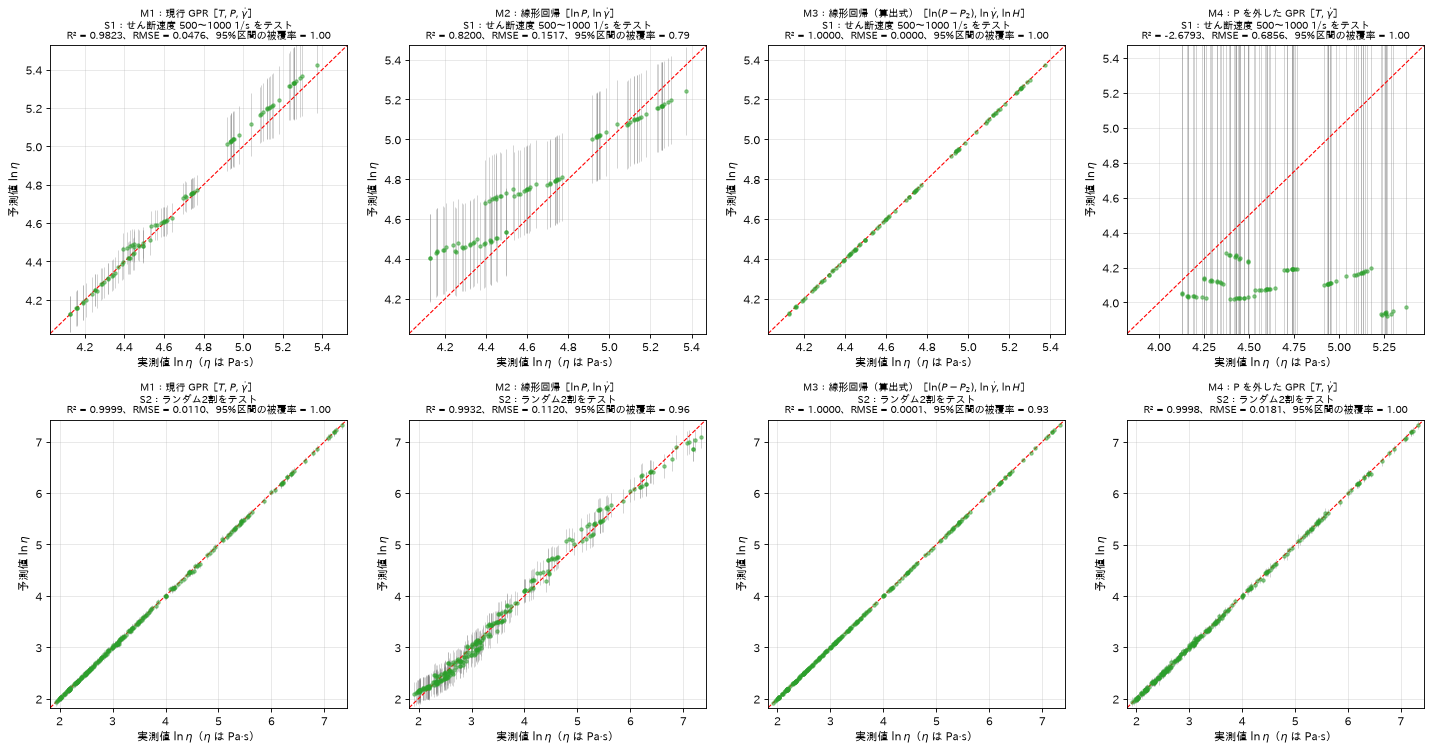

In [9]:
# セル9：パリティ図（2つの分割 × 4つのモデル）
fig, axes = plt.subplots(2, 4, figsize=(18, 9.5))
for i, s in enumerate(SPLITS):
    for j, name in enumerate(MODELS):
        ax = axes[i, j]
        y_t, mu, sd = preds[(s, name)]
        ax.errorbar(y_t, mu, yerr=1.96 * sd, fmt="o", ms=3, alpha=0.5, elinewidth=0.6,
                    color="tab:green", ecolor="gray")
        lo = min(y_t.min(), mu.min()) - 0.1
        hi = max(y_t.max(), mu.max()) + 0.1
        ax.plot([lo, hi], [lo, hi], "r--", lw=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        r = metrics_df.query("split == @s and model == @name").iloc[0]
        ax.set_title(f"{MODELS[name]['label']}\n{SPLIT_LABELS[s]}\n"
                     f"R² = {r['R2_ln_eta']:.4f}、RMSE = {r['RMSE_ln_eta']:.4f}、95%区間の被覆率 = {r['coverage95']:.2f}",
                     fontsize=9)
        ax.set_xlabel(r"実測値 $\ln\eta$（$\eta$ は Pa·s）")
        ax.set_ylabel(r"予測値 $\ln\eta$")
        ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_parity_ln_eta.png"), dpi=FIG_DPI)
plt.show()

## 9. 温度の効果

- (a) データ：同じ厚み・同じ射出率で、設定温度によって粘度がどれだけ違うかを見る。
- (b) 現行モデル M1（S1 で学習）：P を中央値に固定し、流動先端温度を 190 / 210 / 230 ℃ にしたときの予測曲線を描く。

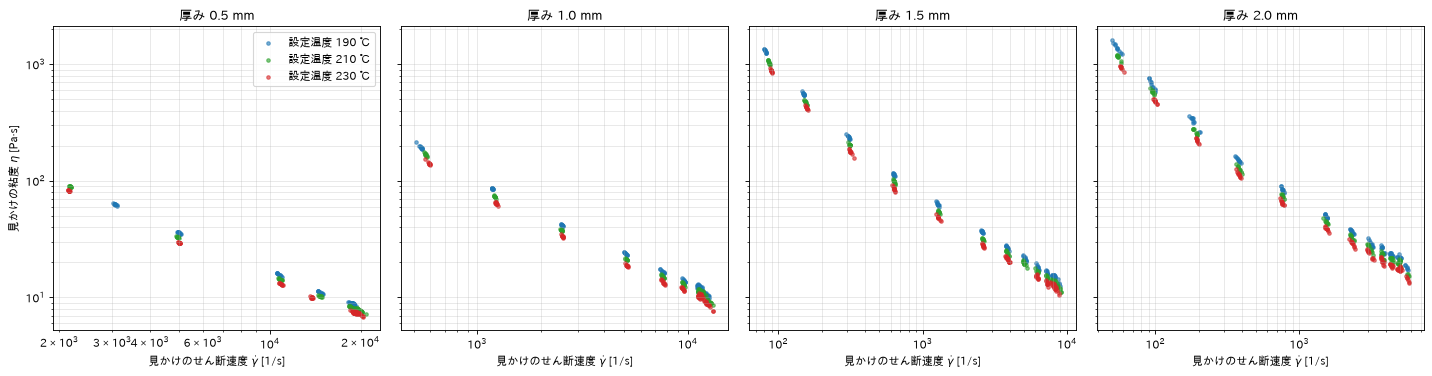

190 ℃ と 230 ℃ の比（同じ厚み・同じ射出率の条件平均。粘度の比 = exp(ln η の差)）
  H = 0.5 mm: 粘度の比 中央値 1.19（範囲 0.76〜1.23）、せん断速度の比 中央値 0.98
  H = 1.0 mm: 粘度の比 中央値 1.24（範囲 1.17〜1.37）、せん断速度の比 中央値 0.99
  H = 1.5 mm: 粘度の比 中央値 1.30（範囲 0.99〜1.47）、せん断速度の比 中央値 0.99
  H = 2.0 mm: 粘度の比 中央値 1.28（範囲 1.22〜1.49）、せん断速度の比 中央値 0.99
  全体: 粘度の比 中央値 1.24


In [10]:
# セル10：データに見られる温度の効果
T_COLORS = {190.0: "tab:blue", 210.0: "tab:green", 230.0: "tab:red"}
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)
for ax, h in zip(axes, np.unique(H)):
    for t in sorted(T_COLORS):
        m = (H == h) & (Tset == t)
        ax.scatter(sr[m], eta[m], s=10, alpha=0.6, color=T_COLORS[t], label=f"設定温度 {t:.0f} ℃")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"厚み {h} mm")
    ax.set_xlabel(r"見かけのせん断速度 $\dot{\gamma}$ [1/s]")
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel(r"見かけの粘度 $\eta$ [Pa·s]")
axes[0].legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig3_data_by_Tset.png"), dpi=FIG_DPI)
plt.show()

# 同じ厚み・同じ射出率の条件どうしで、190 ℃ と 230 ℃ の条件平均を比べる
cmean = df.assign(ln_eta=ln_eta, ln_sr=np.log(sr)).groupby(["Tset_C", COL_H, COL_Q])[["ln_eta", "ln_sr"]].mean()
d = (cmean.xs(190.0, level="Tset_C") - cmean.xs(230.0, level="Tset_C")).dropna()
print("190 ℃ と 230 ℃ の比（同じ厚み・同じ射出率の条件平均。粘度の比 = exp(ln η の差)）")
for h, r in d.groupby(level=COL_H):
    print(f"  H = {h} mm: 粘度の比 中央値 {np.exp(r['ln_eta'].median()):.2f}"
          f"（範囲 {np.exp(r['ln_eta'].min()):.2f}〜{np.exp(r['ln_eta'].max()):.2f}）、"
          f"せん断速度の比 中央値 {np.exp(r['ln_sr'].median()):.2f}")
print(f"  全体: 粘度の比 中央値 {np.exp(d['ln_eta'].median()):.2f}")
d.reset_index().to_csv(os.path.join(OUT_DIR, "temperature_effect_190_vs_230.csv"), index=False, encoding="utf-8-sig")

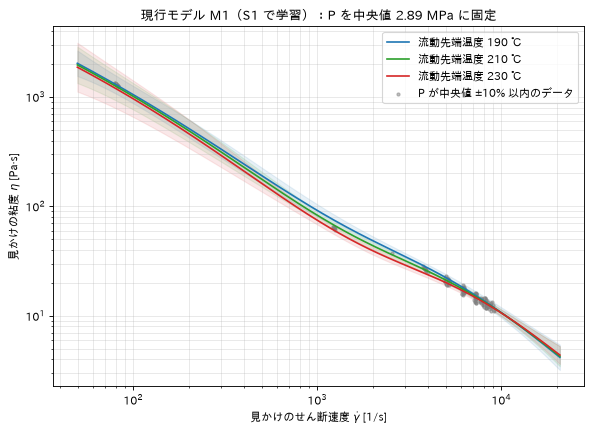

P が中央値 ±10% のショット: 134 行、γ̇ = 79〜9121 1/s
  T_flow = 190 ℃: この範囲での ln η–ln γ̇ の傾き -0.988
  T_flow = 210 ℃: この範囲での ln η–ln γ̇ の傾き -0.992
  T_flow = 230 ℃: この範囲での ln η–ln γ̇ の傾き -0.992
  190 ℃ と 230 ℃ の曲線の差: ln η で最大 0.217（粘度の比 1.24）、平均 0.143


In [11]:
# セル11：現行モデル M1（S1 で学習）の予測曲線。P を中央値に固定し、流動先端温度だけを変える
gp_M1 = fitted[("S1", "M1")]
P_fix = np.median(P)
sr_grid = np.geomspace(sr.min(), sr.max(), 200)
near = np.abs(np.log(P / P_fix)) < np.log(1.1)       # P が中央値の ±10% 以内のショット
fig, ax = plt.subplots(figsize=(7.5, 5.5))
curves = {}
for t in [190.0, 210.0, 230.0]:
    Xg = np.column_stack([np.full_like(sr_grid, np.log(t + 273.15)), np.full_like(sr_grid, np.log(P_fix)), np.log(sr_grid)])
    mu, sd = gp_M1.predict(sc_M1.transform(Xg), return_std=True)
    curves[t] = mu + y_mean
    ax.plot(sr_grid, np.exp(curves[t]), color=T_COLORS[t], label=f"流動先端温度 {t:.0f} ℃")
    ax.fill_between(sr_grid, np.exp(curves[t] - 1.96 * sd), np.exp(curves[t] + 1.96 * sd), color=T_COLORS[t], alpha=0.1)
ax.scatter(sr[near], eta[near], s=8, color="gray", alpha=0.5, label="P が中央値 ±10% 以内のデータ")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"見かけのせん断速度 $\dot{\gamma}$ [1/s]")
ax.set_ylabel(r"見かけの粘度 $\eta$ [Pa·s]")
ax.set_title(f"現行モデル M1（S1 で学習）：P を中央値 {P_fix / 1e6:.2f} MPa に固定")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig4_M1_curves_by_T.png"), dpi=FIG_DPI)
plt.show()

in_range = (sr_grid >= sr[near].min()) & (sr_grid <= sr[near].max())
print(f"P が中央値 ±10% のショット: {near.sum()} 行、γ̇ = {sr[near].min():.0f}〜{sr[near].max():.0f} 1/s")
for t, c in curves.items():
    slope = np.polyfit(np.log(sr_grid[in_range]), c[in_range], 1)[0]
    print(f"  T_flow = {t:.0f} ℃: この範囲での ln η–ln γ̇ の傾き {slope:.3f}")
diff = np.abs(curves[190.0][in_range] - curves[230.0][in_range])
print(f"  190 ℃ と 230 ℃ の曲線の差: ln η で最大 {diff.max():.3f}（粘度の比 {np.exp(diff.max()):.2f}）、平均 {diff.mean():.3f}")

## 10. まとめ

In [12]:
# セル12：主要な数値と保存したファイル
pivot = metrics_df.pivot(index="model", columns="split",
                         values=["R2_ln_eta", "RMSE_ln_eta", "R2_eta", "coverage95", "NLPD"])
print(pivot.round(4).to_string())
print("\n保存したファイル:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", os.path.normpath(os.path.join(OUT_DIR, f)))

      R2_ln_eta         RMSE_ln_eta          R2_eta         coverage95            NLPD        
split        S1      S2          S1      S2      S1      S2         S1      S2      S1      S2
model                                                                                         
M1       0.9823  0.9999      0.0476  0.0110  0.9666  1.0000     1.0000  1.0000 -1.7809 -2.4394
M2       0.8200  0.9932      0.1517  0.1120  0.8794  0.9627     0.7889  0.9574 -0.3563 -0.7695
M3       1.0000  1.0000      0.0000  0.0001  1.0000  1.0000     1.0000  0.9302 -8.4602 -8.0632
M4      -2.6793  0.9998      0.6856  0.0181 -1.6440  0.9998     1.0000  0.9961  1.1729 -2.2789

保存したファイル:
   ..\results\step2\fig1_formula_check.png
   ..\results\step2\fig2_parity_ln_eta.png
   ..\results\step2\fig3_data_by_Tset.png
   ..\results\step2\fig4_M1_curves_by_T.png
   ..\results\step2\formula_check.csv
   ..\results\step2\kernels.csv
   ..\results\step2\metrics.csv
   ..\results\step2\ols_coefficients.csv
   ..\res